# Credit Default Risk Prediction using Consumer Credit Data
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler  # For Scaleing the values to comparable range
from sklearn.impute import KNNImputer   # To Impute Values

from statsmodels.stats.outliers_influence import variance_inflation_factor  # To find Variance Inflation Factor

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve, roc_curve

In [2]:
df_train = pd.read_csv("Data\GiveMeSomeCredit-training.csv")
df_train.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
print("Shape:", df_train.shape)
df_train.info()
df_train.describe()

Shape: (150000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [4]:
pd.set_option('display.float_format', '{:.2f}'.format)  # Displays scientific numbers (Real numbers) as normal numbers

In [5]:
df_train.drop("Unnamed: 0", axis=1, inplace=True)   # Removing as it's the Serial number column and is not needed

df_train.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [6]:
# Analyze Age Data
df_train[df_train["age"]==0]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
65695,0,1.00,0,1,0.44,6000.00,6,0,2,0,2.00


In [7]:
# Surprizing fact is that we see Age as Zero in a line
# This is not realistic, since borrowers cannot have credit history at age 0
df_train = df_train[df_train['age'] > 0]    # Lets ignore this instance as it is just a row

In [8]:
df_train[['NumberOfTimes90DaysLate']].value_counts()

NumberOfTimes90DaysLate
0                          141661
1                            5243
2                            1555
3                             667
4                             291
98                            264
5                             131
6                              80
7                              38
8                              21
9                              19
10                              8
11                              5
96                              5
13                              4
14                              2
12                              2
15                              2
17                              1
Name: count, dtype: int64

In [9]:
df_train[df_train['NumberOfTimes90DaysLate'] > 50]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1733,1,1.00,27,98,0.00,2700.00,0,98,0,98,0.00
2286,0,1.00,22,98,0.00,NaN,0,98,0,98,0.00
3884,0,1.00,38,98,12.00,NaN,0,98,0,98,0.00
4417,0,1.00,21,98,0.00,0.00,0,98,0,98,0.00
4705,0,1.00,21,98,0.00,2000.00,0,98,0,98,0.00
...,...,...,...,...,...,...,...,...,...,...,...
147774,1,1.00,68,98,255.00,NaN,0,98,0,98,0.00
149153,1,1.00,24,98,54.00,NaN,0,98,0,98,0.00
149239,0,1.00,26,98,0.00,2000.00,0,98,0,98,0.00
149439,1,1.00,34,98,9.00,NaN,0,98,0,98,0.00


In [10]:
df_train[['NumberOfTime60-89DaysPastDueNotWorse']].value_counts()

NumberOfTime60-89DaysPastDueNotWorse
0                                       142395
1                                         5731
2                                         1118
3                                          318
98                                         264
4                                          105
5                                           34
6                                           16
7                                            9
96                                           5
8                                            2
11                                           1
9                                            1
Name: count, dtype: int64

In [11]:
df_train[['NumberOfTime30-59DaysPastDueNotWorse']].value_counts()

NumberOfTime30-59DaysPastDueNotWorse
0                                       126018
1                                        16032
2                                         4598
3                                         1754
4                                          747
5                                          342
98                                         264
6                                          140
7                                           54
8                                           25
9                                           12
96                                           5
10                                           4
12                                           2
11                                           1
13                                           1
Name: count, dtype: int64

In [12]:
# Having values like 96 and 98 in default count is not realistic, hence, changing it to null and impute at a later stage
cols = [
'NumberOfTimes90DaysLate',
'NumberOfTime30-59DaysPastDueNotWorse',
'NumberOfTime60-89DaysPastDueNotWorse'
]

for col in cols:
    df_train.loc[df_train[col] >= 90, col] = np.nan

In [13]:
df_train.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse      269
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                   269
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse      269
NumberOfDependents                       3924
dtype: int64

In [14]:
df_train['SeriousDlqin2yrs'].value_counts(normalize=True)

SeriousDlqin2yrs
0   0.93
1   0.07
Name: proportion, dtype: float64

(0.0, 153970.30000000002)

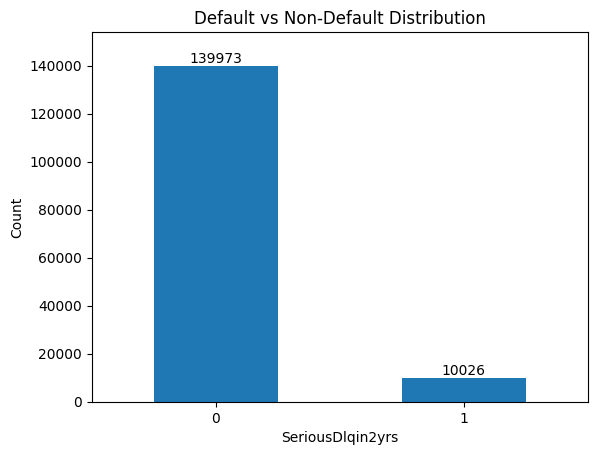

In [15]:
# Checking how balanced is the target data
target_Count = df_train["SeriousDlqin2yrs"].value_counts()
ax = target_Count.plot(kind='bar')

plt.ylabel("Count")
plt.title("Default vs Non-Default Distribution")

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=0)
plt.ylim(0, max(target_Count) * 1.1)

In [16]:
missing = df_train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

MonthlyIncome                           29731
NumberOfDependents                       3924
NumberOfTime30-59DaysPastDueNotWorse      269
NumberOfTimes90DaysLate                   269
NumberOfTime60-89DaysPastDueNotWorse      269
dtype: int64


In [17]:
missing_percent = (df_train.isnull().sum()/len(df_train))*100
missing_percent.sort_values(ascending=False)

MonthlyIncome                          19.82
NumberOfDependents                      2.62
NumberOfTimes90DaysLate                 0.18
NumberOfTime60-89DaysPastDueNotWorse    0.18
NumberOfTime30-59DaysPastDueNotWorse    0.18
SeriousDlqin2yrs                        0.00
RevolvingUtilizationOfUnsecuredLines    0.00
age                                     0.00
DebtRatio                               0.00
NumberOfOpenCreditLinesAndLoans         0.00
NumberRealEstateLoansOrLines            0.00
dtype: float64

In [18]:
# Calculate counts and percentages
missing_count = df_train.isnull().sum()
missing_percent = (df_train.isnull().sum() / len(df_train)) * 100

# Combine into a single DataFrame
missing_data = pd.concat([missing_count, missing_percent], axis=1, keys=['Total Missing', 'Percentage (%)'])

# Sort by percentage descending to see the worst offenders first
missing_data = missing_data.sort_values(by='Percentage (%)', ascending=False)

print(missing_data)

                                      Total Missing  Percentage (%)
MonthlyIncome                                 29731           19.82
NumberOfDependents                             3924            2.62
NumberOfTimes90DaysLate                         269            0.18
NumberOfTime60-89DaysPastDueNotWorse            269            0.18
NumberOfTime30-59DaysPastDueNotWorse            269            0.18
SeriousDlqin2yrs                                  0            0.00
RevolvingUtilizationOfUnsecuredLines              0            0.00
age                                               0            0.00
DebtRatio                                         0            0.00
NumberOfOpenCreditLinesAndLoans                   0            0.00
NumberRealEstateLoansOrLines                      0            0.00


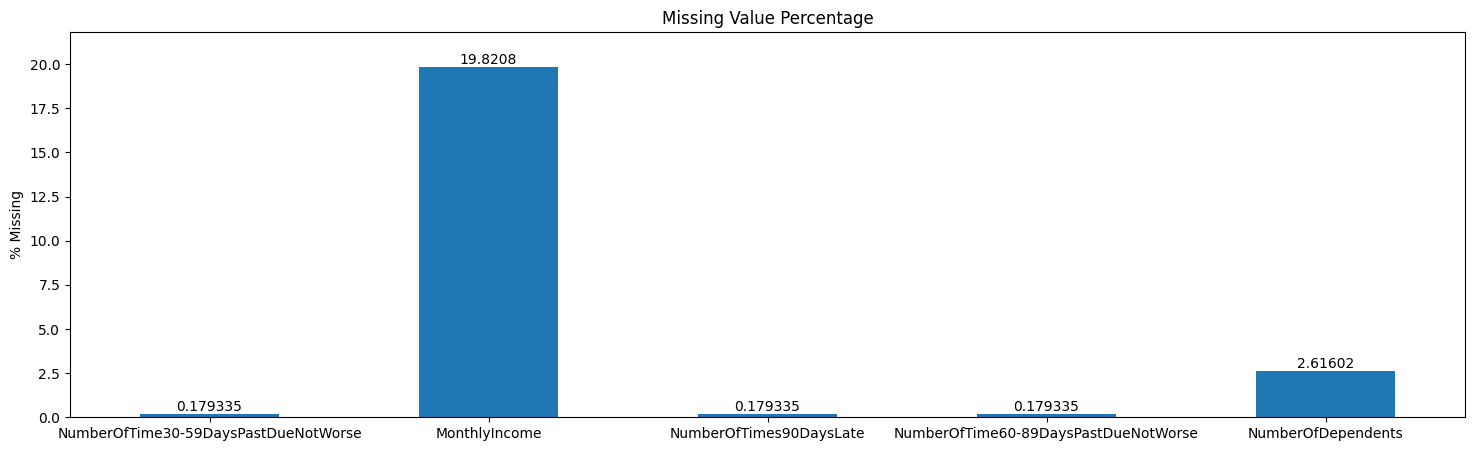

In [19]:
plt.figure(figsize=(18,5))

ax = missing_percent[missing_percent > 0].plot(kind='bar')
plt.title("Missing Value Percentage")
plt.ylabel("% Missing")

for container in ax.containers:
    ax.bar_label(container)

plt.ylim(0, max(missing_percent) * 1.1)

plt.xticks(rotation=0)

plt.show()

In [20]:
target_col = "SeriousDlqin2yrs" # Target Feature

# Get all features except target
features_df = df_train.drop(columns=[target_col])

num_cols = features_df.select_dtypes(include=['number']).columns.tolist()   # Store Numerical Columns in a list
cat_cols = features_df.select_dtypes(include=['object', 'category']).columns.tolist()   # Store Categorical Columns in a list

print(f"There are {len(num_cols)} Numerical features: {num_cols}")
print(f"There are {len(cat_cols)} Categorical features: {cat_cols}")

There are 10 Numerical features: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']
There are 0 Categorical features: []


## Distribution Analysis
___

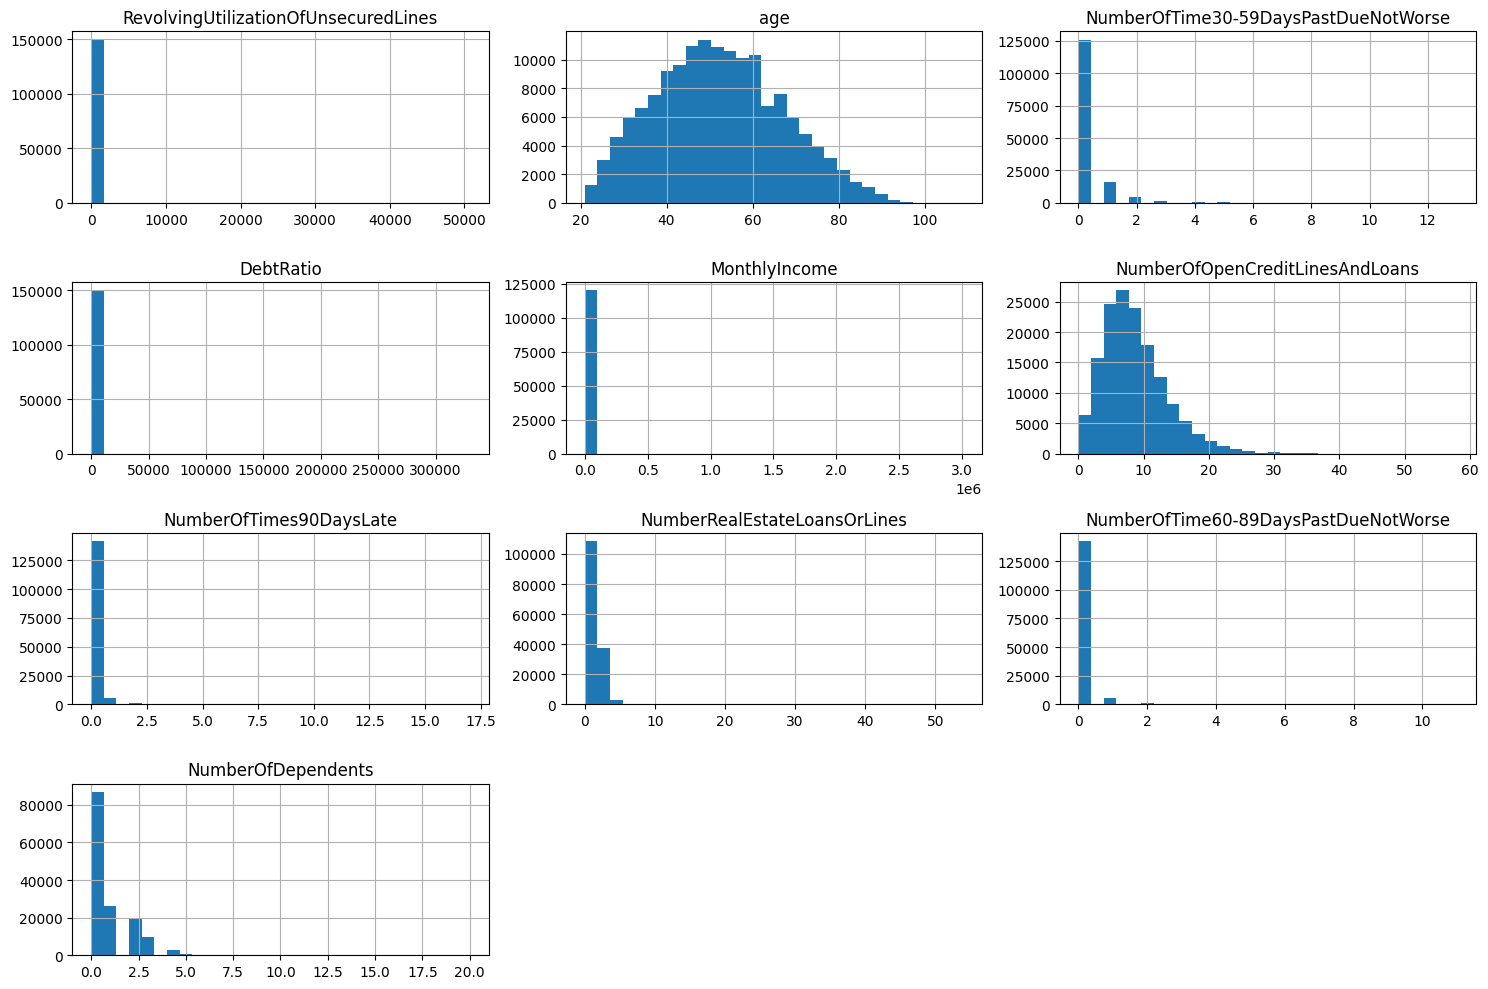

In [21]:
df_train[num_cols].hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

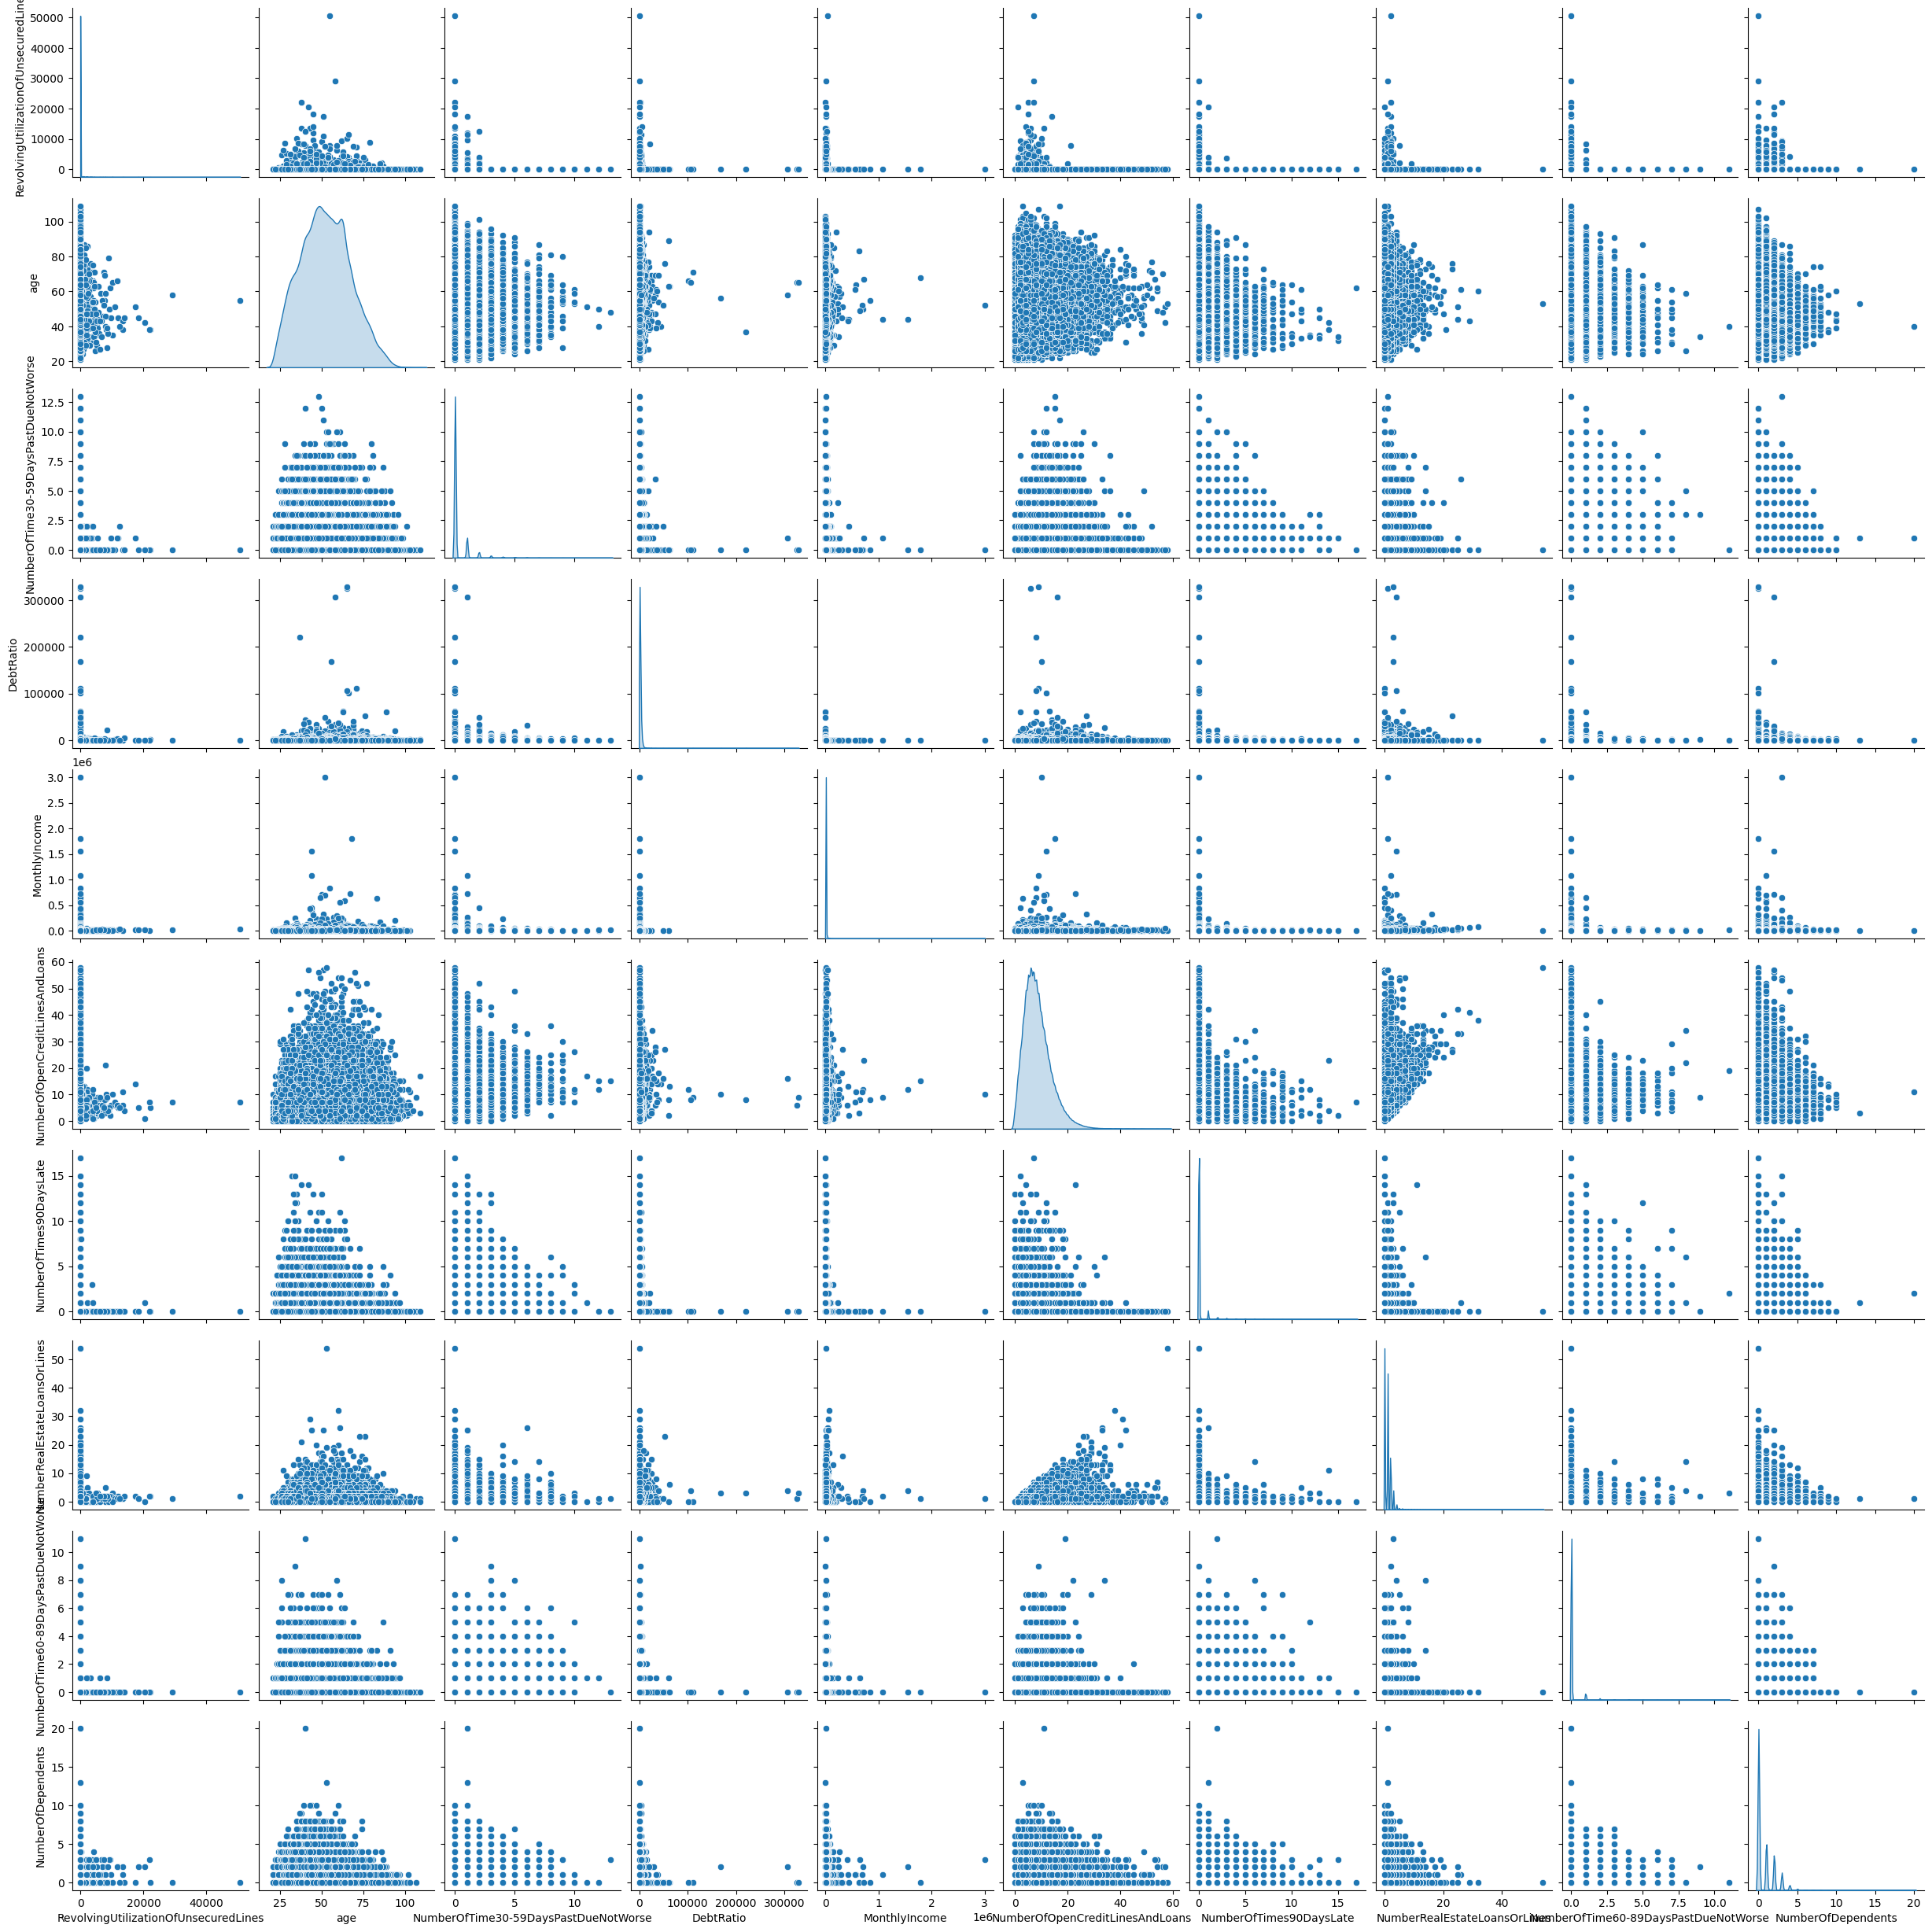

In [22]:
sns.pairplot(df_train[num_cols], diag_kind='kde')

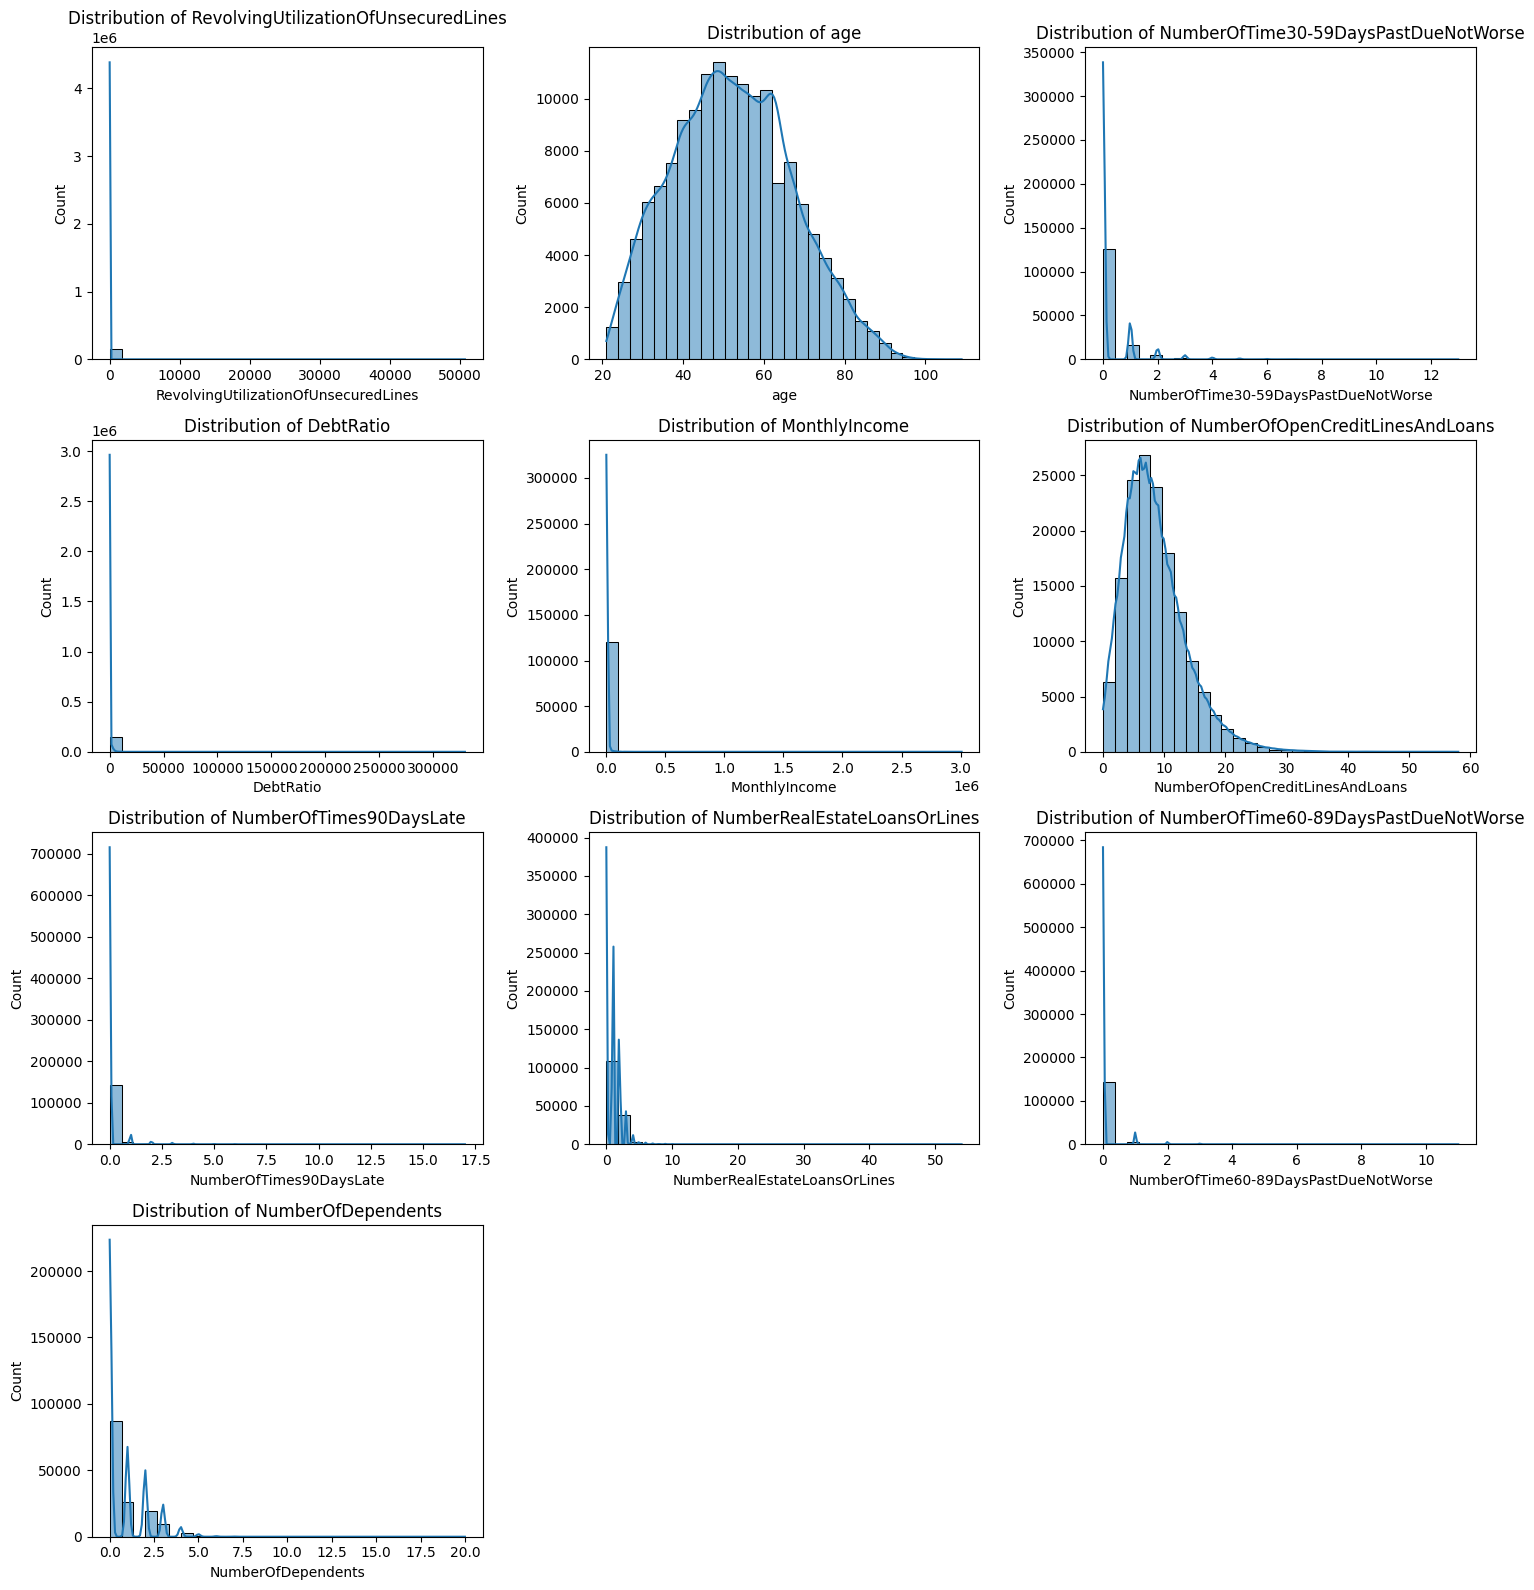

In [23]:
# Setting up the figure size and the grid layout
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 4))

# Looping through columns to create a histplot for each
for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.histplot(df_train[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

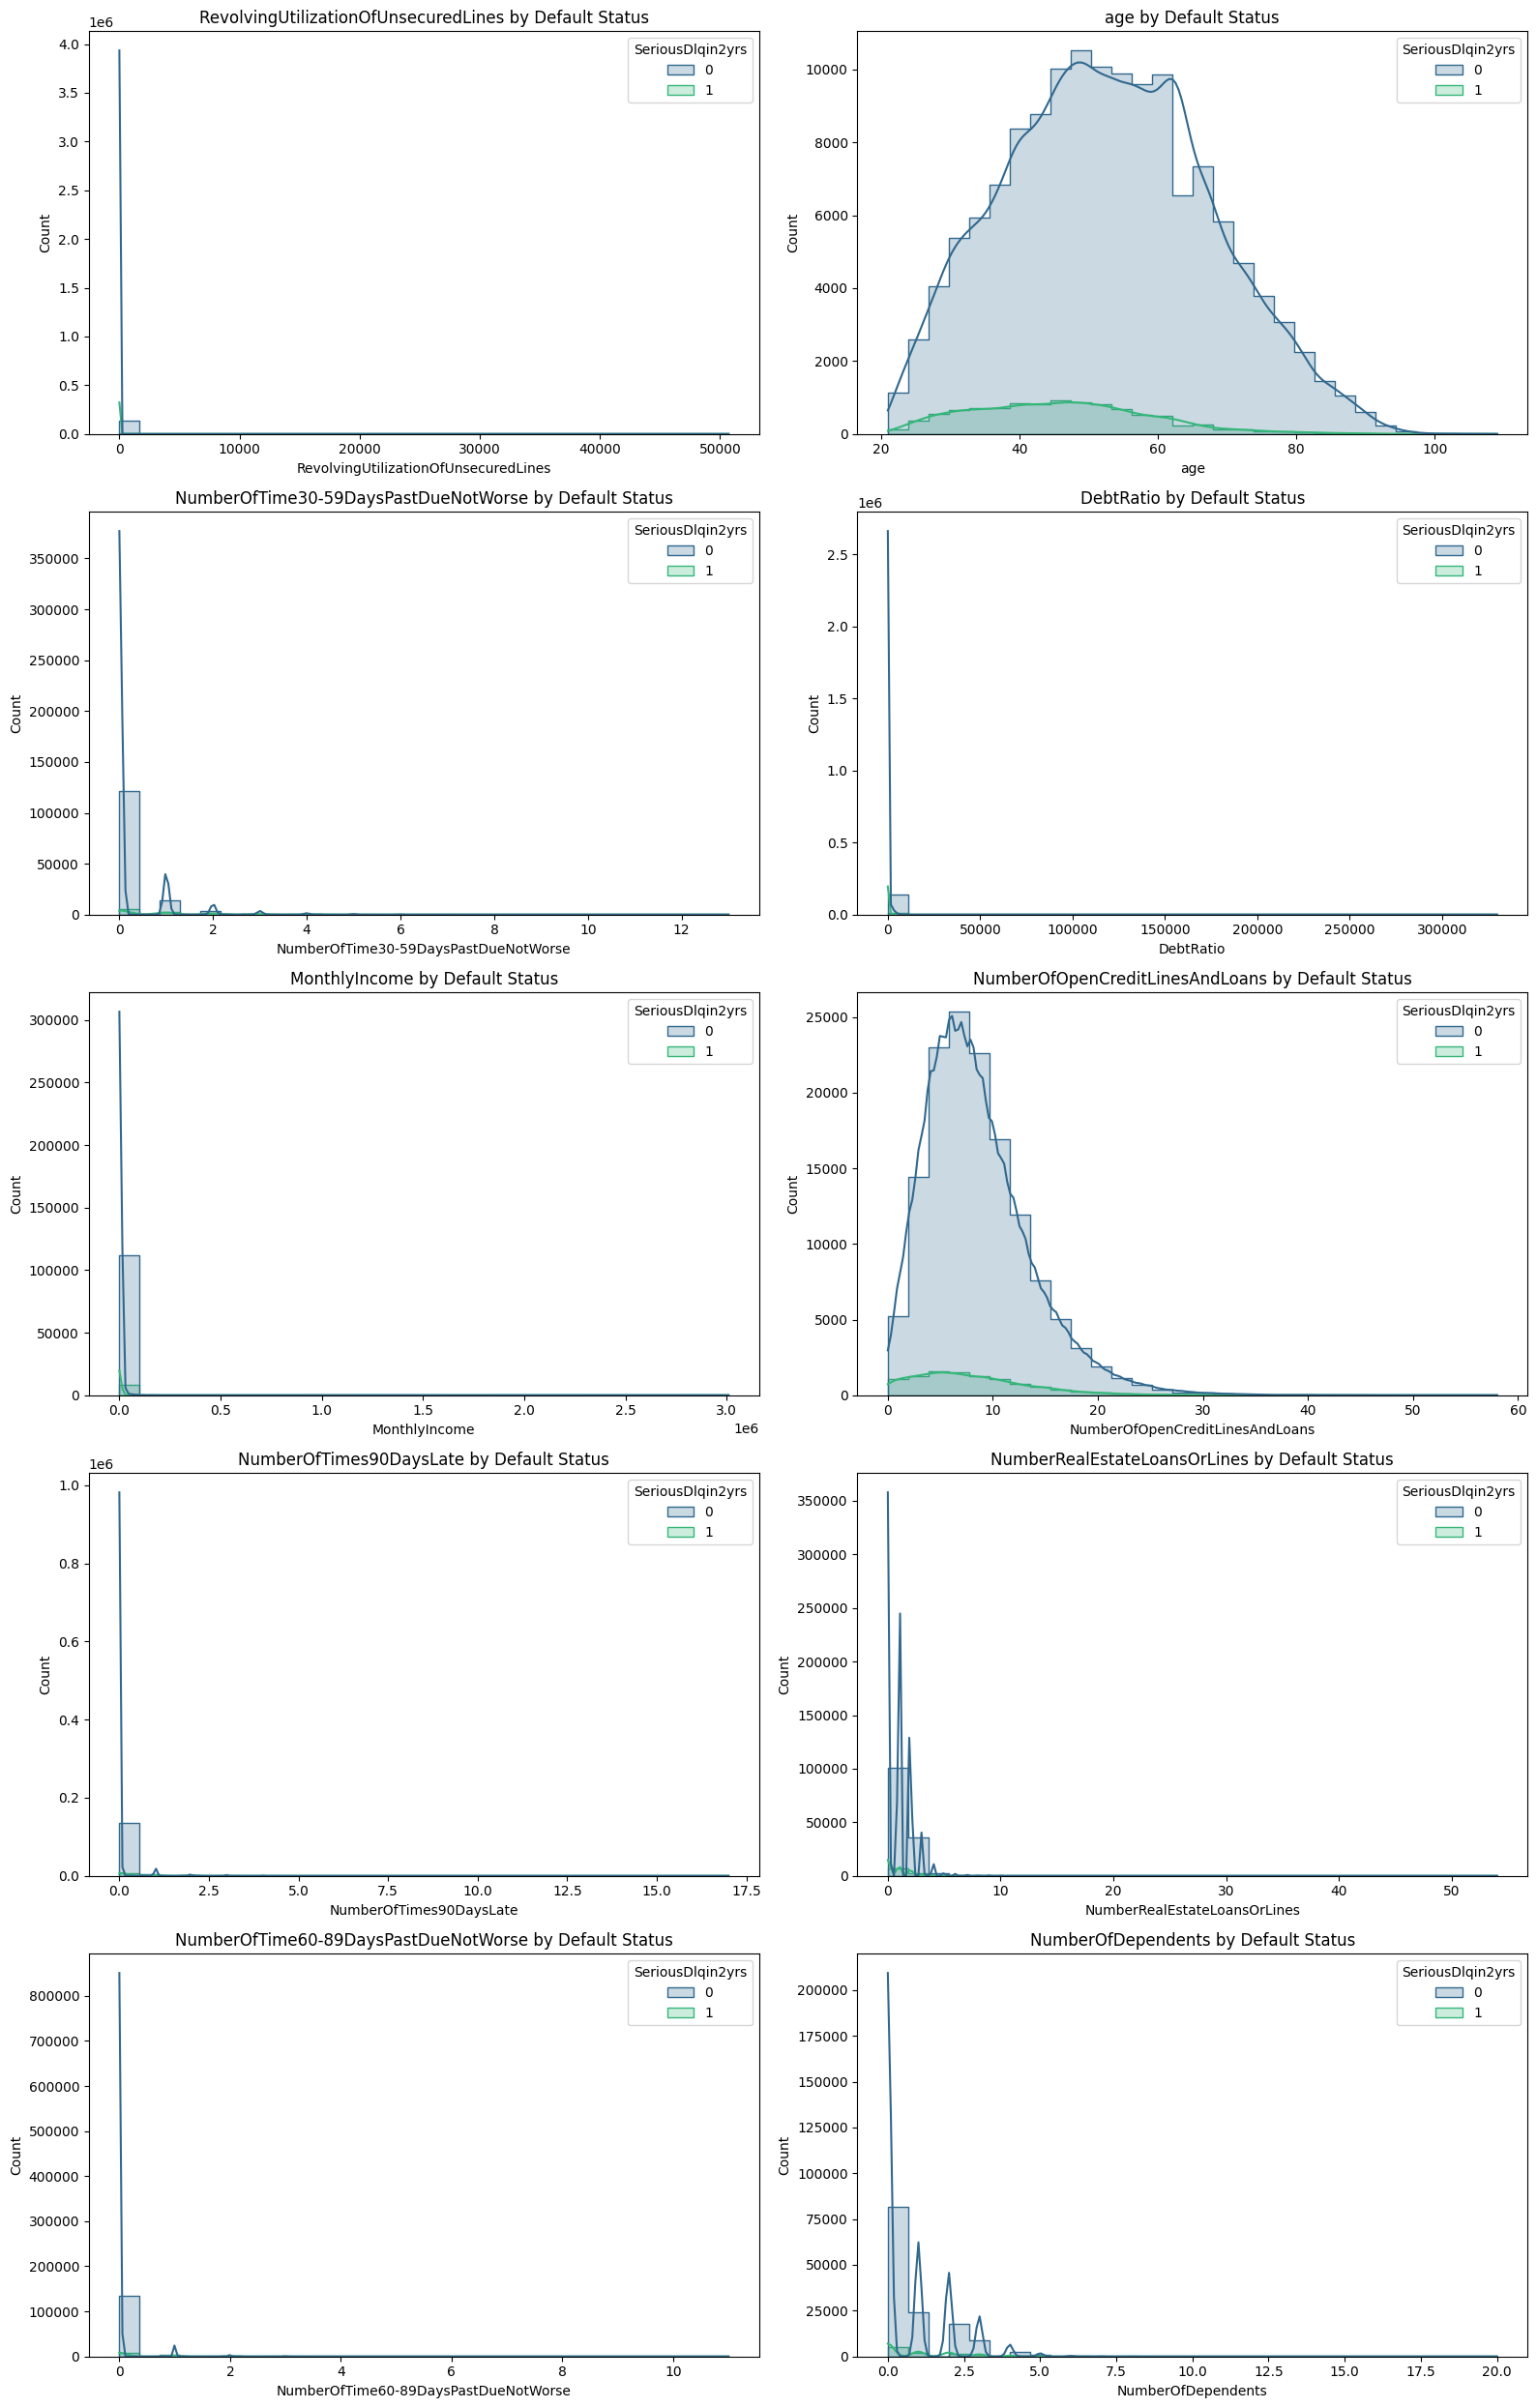

In [24]:
n_cols = 2
n_rows = (len(num_cols) + n_cols - 1) // n_cols 

plt.figure(figsize=(16, n_rows * 5))

# Loop and plot with 'hue'
for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    
    sns.histplot(
        data=df_train, x=col, hue=target_col,
        bins=30, kde=True, element="step", palette="viridis"
    )
    
    plt.title(f'{col} by Default Status')

plt.tight_layout()
plt.show()

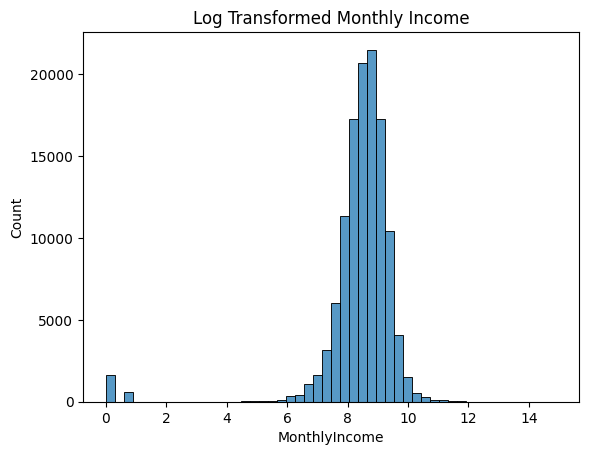

In [25]:
# Monthly Income plot is skewed and the X-axis is displayed in log terms
# hence, plotting after converting in log terms

sns.histplot(np.log1p(df_train['MonthlyIncome']), bins=50)

plt.title("Log Transformed Monthly Income")

plt.show()

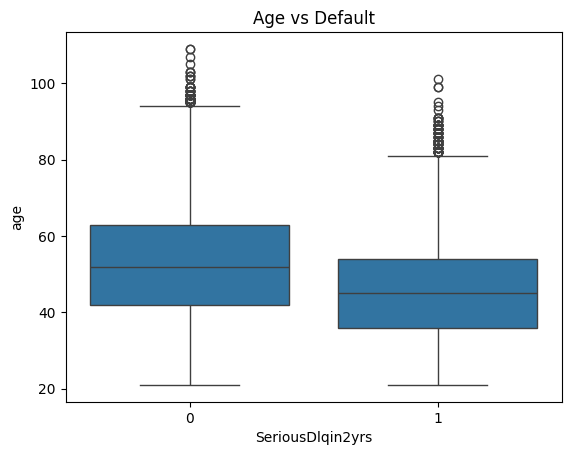

In [26]:
# Age vs Default
sns.boxplot(x='SeriousDlqin2yrs', y='age', data=df_train)
plt.title("Age vs Default")
plt.show()

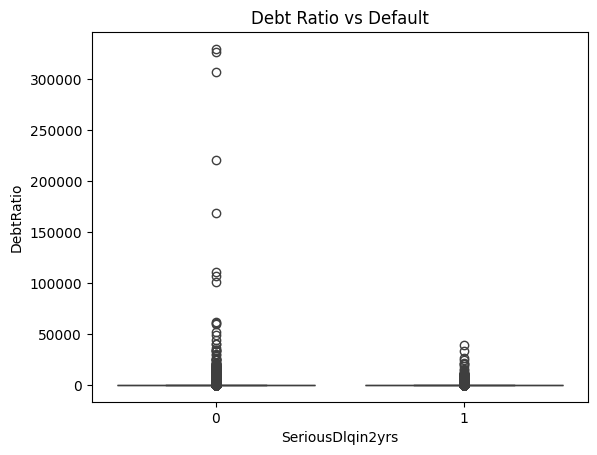

In [27]:
# Debt Ratio vs Default
sns.boxplot(x='SeriousDlqin2yrs', y='DebtRatio', data=df_train)
plt.title("Debt Ratio vs Default")
plt.show()

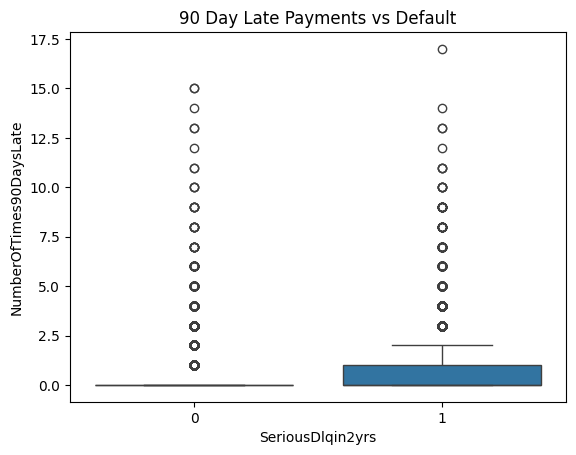

In [28]:
# Delinquency history vs Default 
sns.boxplot(x='SeriousDlqin2yrs', y='NumberOfTimes90DaysLate', data=df_train)
plt.title("90 Day Late Payments vs Default")
plt.show()

## Outlier Detection
---

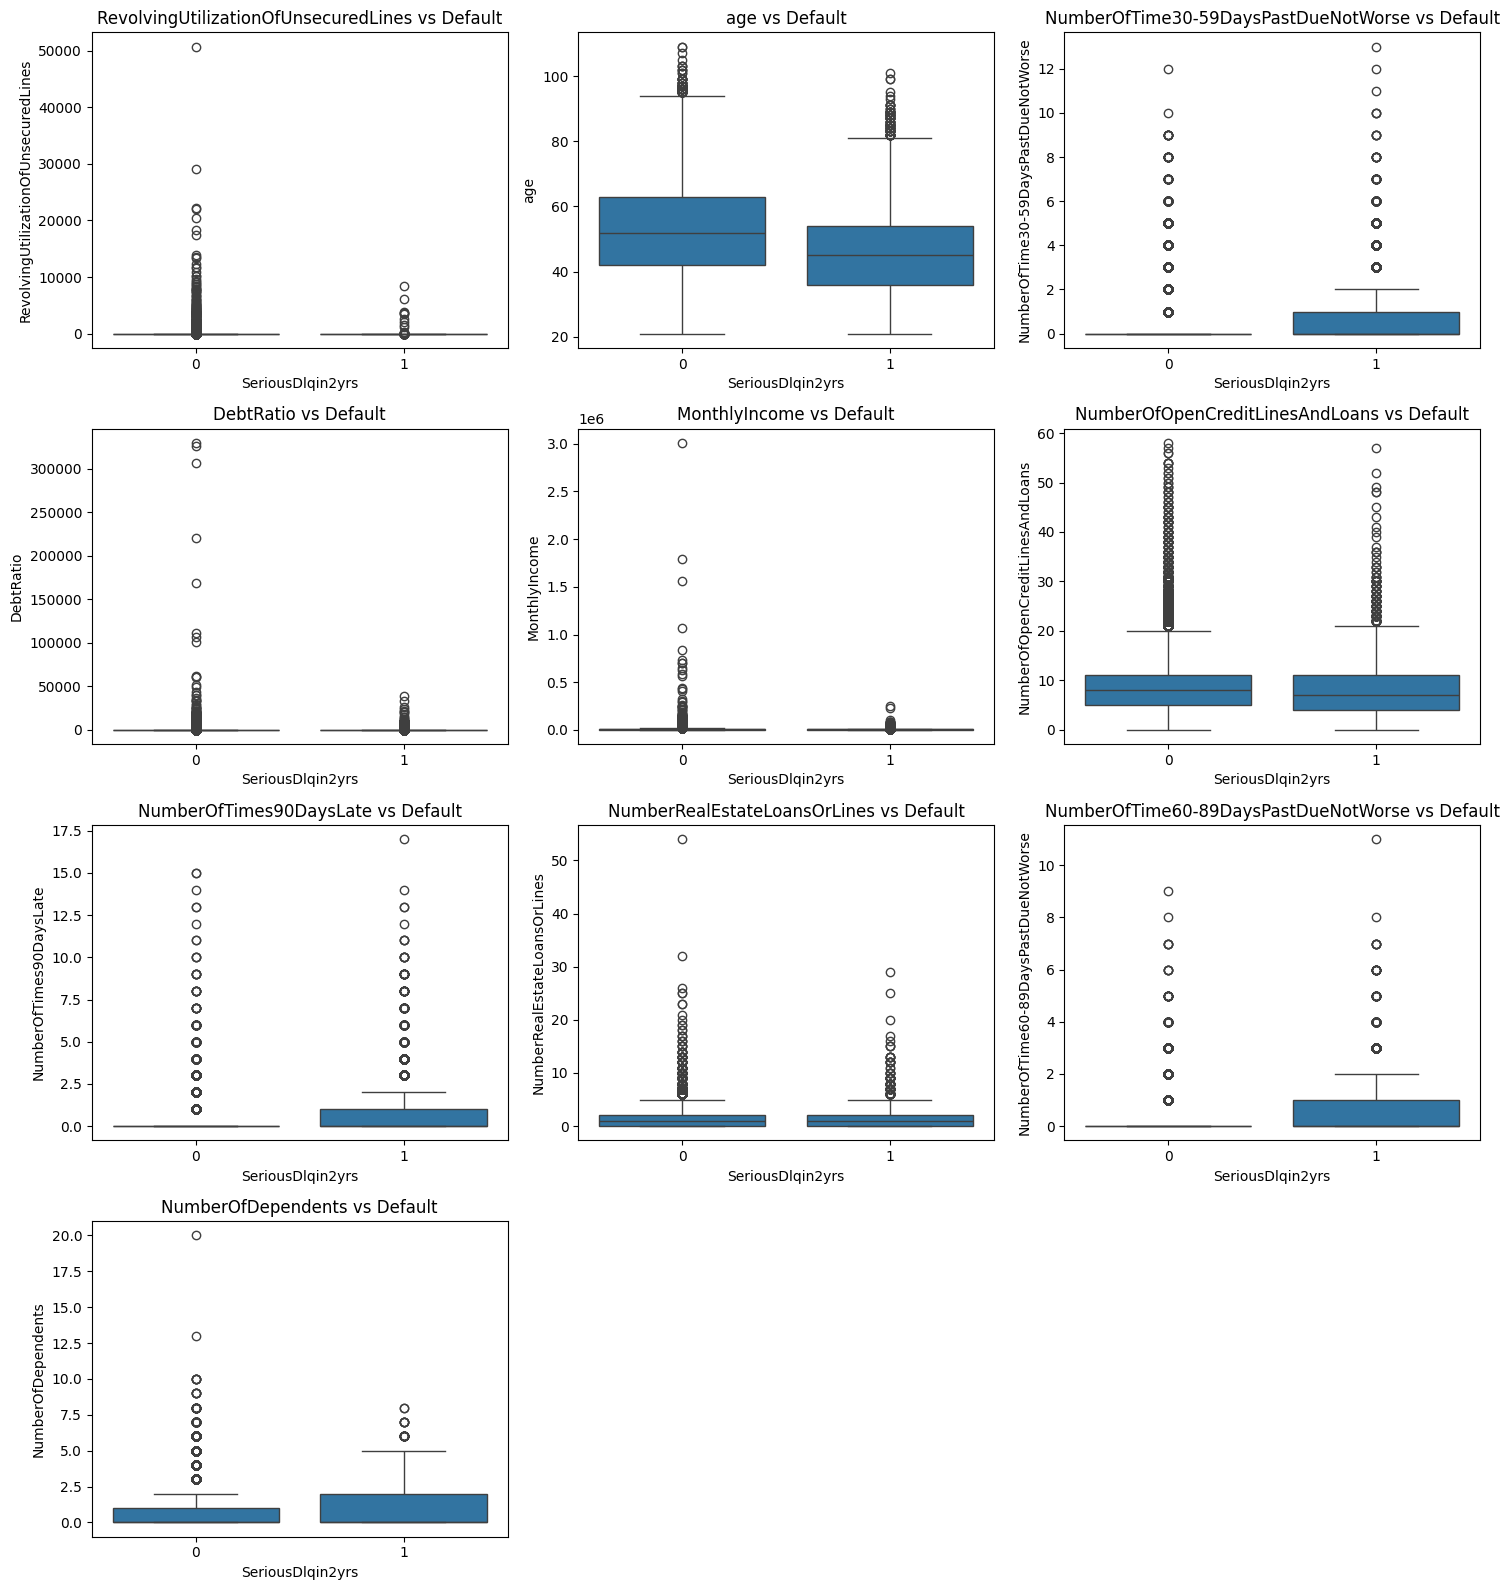

In [29]:
# Setting up the figure size and the grid layout
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 4))

# Looping through columns to create a boxplot for each to understand outliers
for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.boxplot(x='SeriousDlqin2yrs', y=col, data=df_train)
    plt.title(f'{col} vs Default')

plt.tight_layout()
plt.show()

In [30]:
def Outlier_Count_IQR(dataframe, features, method):
    
    for i in features:
        
        if method == "IQR":
            Q1 = dataframe[i].quantile(0.75)
            Q3 = dataframe[i].quantile(0.25)
            IQR = Q1 - Q3
            
            Lower_fence = Q1 - 1.5 * IQR
            Upper_fence = Q3 + 1.5 * IQR

            outliers = dataframe[(dataframe[i] < Lower_fence) | (dataframe[i] > Upper_fence)]
            
            print('No. of outliers in {i} detected using IQR: {lenOfOutliers}'.format(i=i, lenOfOutliers = len(outliers)))
        
        elif method == "Winsorization":
            Lower_fence = dataframe[i].quantile(0.01)
            Upper_fence = dataframe[i].quantile(0.99)

            outliers = dataframe[(dataframe[i] < Lower_fence) | (dataframe[i] > Upper_fence)]
            
            print('No. of outliers in {i} detected using Winsorization: {lenOfOutliers}'.format(i=i, lenOfOutliers = len(outliers)))


In [31]:
Outlier_Count_IQR(df_train, ["DebtRatio", "RevolvingUtilizationOfUnsecuredLines", "MonthlyIncome"], "IQR")

No. of outliers in DebtRatio detected using IQR: 33343
No. of outliers in RevolvingUtilizationOfUnsecuredLines detected using IQR: 24015
No. of outliers in MonthlyIncome detected using IQR: 19595


In [32]:
Outlier_Count_IQR(df_train, ["DebtRatio", "RevolvingUtilizationOfUnsecuredLines", "MonthlyIncome"], "Winsorization")

No. of outliers in DebtRatio detected using Winsorization: 1500
No. of outliers in RevolvingUtilizationOfUnsecuredLines detected using Winsorization: 1500
No. of outliers in MonthlyIncome detected using Winsorization: 1168


## Correlation Analysis
---

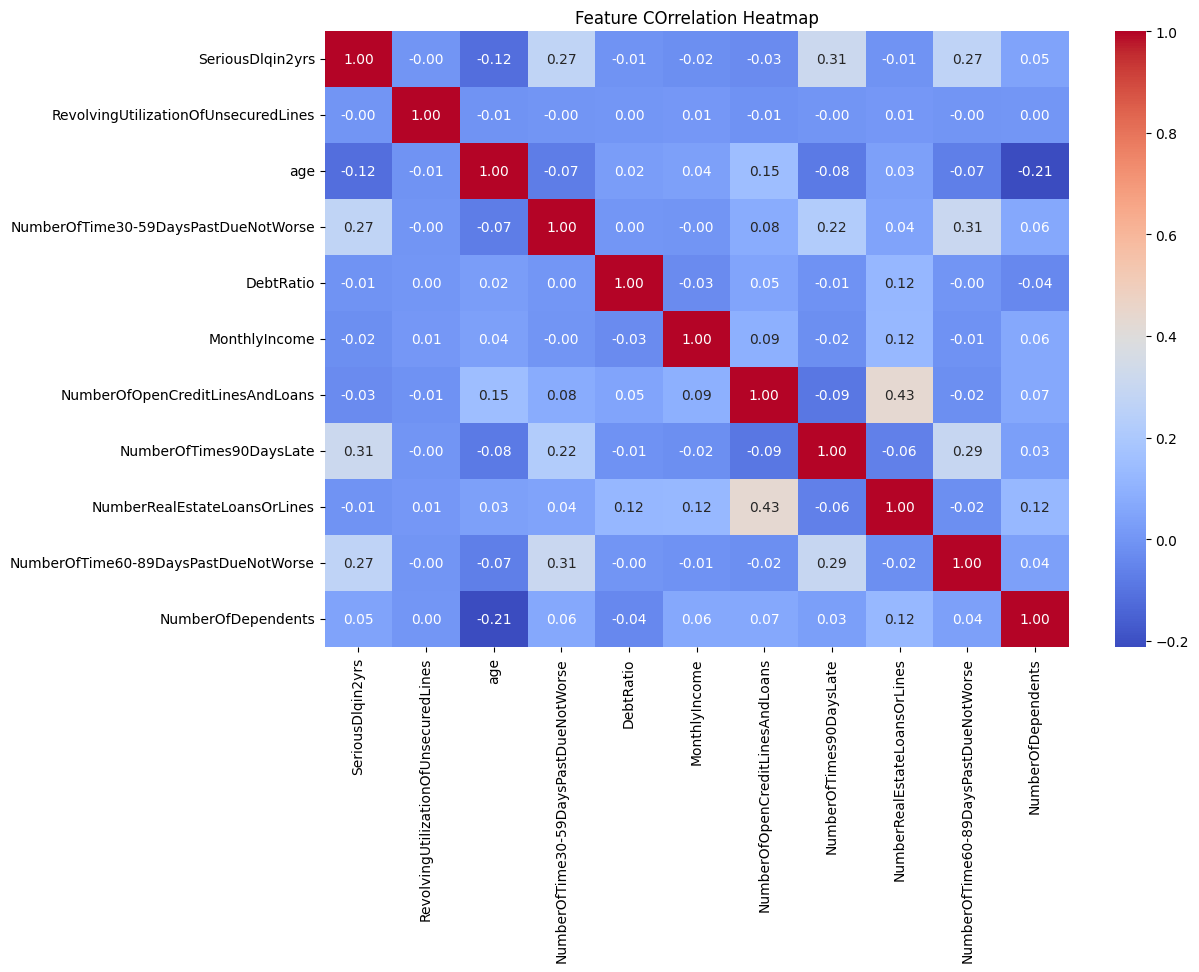

In [33]:
corr = df_train.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature COrrelation Heatmap")
plt.show()

In [34]:
# Display strongest correlations
corr['SeriousDlqin2yrs'].sort_values(ascending=False)

SeriousDlqin2yrs                        1.00
NumberOfTimes90DaysLate                 0.31
NumberOfTime30-59DaysPastDueNotWorse    0.27
NumberOfTime60-89DaysPastDueNotWorse    0.27
NumberOfDependents                      0.05
RevolvingUtilizationOfUnsecuredLines   -0.00
NumberRealEstateLoansOrLines           -0.01
DebtRatio                              -0.01
MonthlyIncome                          -0.02
NumberOfOpenCreditLinesAndLoans        -0.03
age                                    -0.12
Name: SeriousDlqin2yrs, dtype: float64

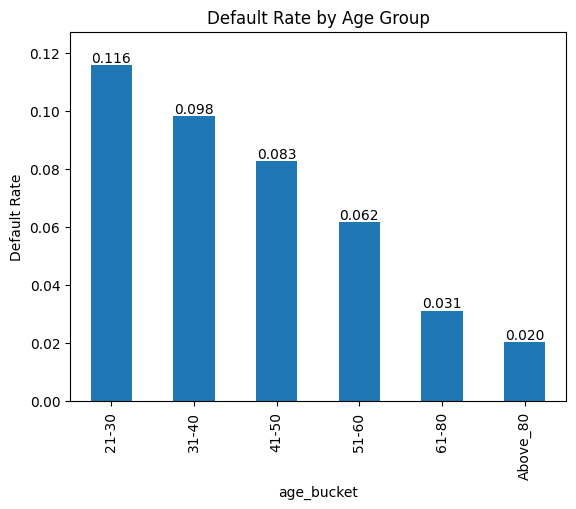

In [35]:
bins = [float('-inf'), 20, 30, 40, 50, 60, 80, float('inf')]
labels = ['Below_20', '21-30', '31-40', '41-50', '51-60', '61-80', 'Above_80']

df_train['age_bucket'] = pd.cut(df_train['age'], bins=bins, labels=labels)

risk_by_age = df_train.groupby('age_bucket', observed=True)['SeriousDlqin2yrs'].mean()

ax = risk_by_age.plot(kind='bar')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')

plt.title("Default Rate by Age Group")
plt.ylabel("Default Rate")
plt.ylim(0, risk_by_age.max() * 1.1)
plt.show()

In [36]:
age_analysis = df_train.groupby('age_bucket', observed=False)['SeriousDlqin2yrs'].agg(['mean', 'count'])

print(age_analysis)

            mean  count
age_bucket             
Below_20     NaN      0
21-30       0.12  10757
31-40       0.10  24339
41-50       0.08  35037
51-60       0.06  34806
61-80       0.03  40124
Above_80    0.02   4936


> From the above analysis we understand that the people aged between 20 and 30 defaults the most with 12% of people defaulting

In [37]:
df_train

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,age_bucket
0,1,0.77,45,2.00,0.80,9120.00,13,0.00,6,0.00,2.00,41-50
1,0,0.96,40,0.00,0.12,2600.00,4,0.00,0,0.00,1.00,31-40
2,0,0.66,38,1.00,0.09,3042.00,2,1.00,0,0.00,0.00,31-40
3,0,0.23,30,0.00,0.04,3300.00,5,0.00,0,0.00,0.00,21-30
4,0,0.91,49,1.00,0.02,63588.00,7,0.00,1,0.00,0.00,41-50
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,0,0.04,74,0.00,0.23,2100.00,4,0.00,1,0.00,0.00,61-80
149996,0,0.30,44,0.00,0.72,5584.00,4,0.00,1,0.00,2.00,41-50
149997,0,0.25,58,0.00,3870.00,NaN,18,0.00,1,0.00,0.00,51-60
149998,0,0.00,30,0.00,0.00,5716.00,4,0.00,0,0.00,0.00,21-30


In [38]:
df_train.drop(["age_bucket"], axis=1, inplace=True)

In [39]:
df_train

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.77,45,2.00,0.80,9120.00,13,0.00,6,0.00,2.00
1,0,0.96,40,0.00,0.12,2600.00,4,0.00,0,0.00,1.00
2,0,0.66,38,1.00,0.09,3042.00,2,1.00,0,0.00,0.00
3,0,0.23,30,0.00,0.04,3300.00,5,0.00,0,0.00,0.00
4,0,0.91,49,1.00,0.02,63588.00,7,0.00,1,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...
149995,0,0.04,74,0.00,0.23,2100.00,4,0.00,1,0.00,0.00
149996,0,0.30,44,0.00,0.72,5584.00,4,0.00,1,0.00,2.00
149997,0,0.25,58,0.00,3870.00,NaN,18,0.00,1,0.00,0.00
149998,0,0.00,30,0.00,0.00,5716.00,4,0.00,0,0.00,0.00


### Split the dataset into Training and Testing data

In [40]:
# Importing the Testing Dataset
df_test = pd.read_csv("Data\GiveMeSomeCredit-testing.csv")
df_test.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,NaN,0.89,43,0,0.18,5700.00,4,0,0,0,0.00
1,2,NaN,0.46,57,0,0.53,9141.00,15,0,4,0,2.00
2,3,NaN,0.04,59,0,0.69,5083.00,12,0,1,0,2.00
3,4,NaN,0.28,38,1,0.93,3200.00,7,0,2,0,0.00
4,5,NaN,1.00,27,0,0.02,3865.00,4,0,0,0,1.00


In [41]:
df_test.info()
df_test.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101503 entries, 0 to 101502
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            101503 non-null  int64  
 1   SeriousDlqin2yrs                      0 non-null       float64
 2   RevolvingUtilizationOfUnsecuredLines  101503 non-null  float64
 3   age                                   101503 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  101503 non-null  int64  
 5   DebtRatio                             101503 non-null  float64
 6   MonthlyIncome                         81400 non-null   float64
 7   NumberOfOpenCreditLinesAndLoans       101503 non-null  int64  
 8   NumberOfTimes90DaysLate               101503 non-null  int64  
 9   NumberRealEstateLoansOrLines          101503 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  101503 non-null  int64  
 11  

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,101503.00,0.00,101503.00,101503.00,101503.00,101503.00,81400.00,101503.00,101503.00,101503.00,101503.00,98877.00
mean,50752.00,NaN,5.31,52.41,0.45,344.48,6855.04,8.45,0.30,1.01,0.27,0.77
std,29301.54,NaN,196.16,14.78,4.54,1632.60,36508.60,5.14,4.52,1.11,4.50,1.14
min,1.00,NaN,0.00,21.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,25376.50,NaN,0.03,41.00,0.00,0.17,3408.00,5.00,0.00,0.00,0.00,0.00
50%,50752.00,NaN,0.15,52.00,0.00,0.36,5400.00,8.00,0.00,1.00,0.00,0.00
75%,76127.50,NaN,0.56,63.00,0.00,0.85,8200.00,11.00,0.00,2.00,0.00,1.00
max,101503.00,NaN,21821.00,104.00,98.00,268326.00,7727000.00,85.00,98.00,37.00,98.00,43.00


In [42]:
df_test.drop("Unnamed: 0", axis=1, inplace=True)
df_test.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,NaN,0.89,43,0,0.18,5700.00,4,0,0,0,0.00
1,NaN,0.46,57,0,0.53,9141.00,15,0,4,0,2.00
2,NaN,0.04,59,0,0.69,5083.00,12,0,1,0,2.00
3,NaN,0.28,38,1,0.93,3200.00,7,0,2,0,0.00
4,NaN,1.00,27,0,0.02,3865.00,4,0,0,0,1.00


In [43]:
# No. of Missing values in Testing Data
missing_test = df_test.isnull().sum()
missing_test[missing_test > 0]

SeriousDlqin2yrs      101503
MonthlyIncome          20103
NumberOfDependents      2626
dtype: int64

In [44]:
# No. of Missing values in Training Data
missing_train = df_train.isnull().sum()
missing_train[missing_train > 0]

NumberOfTime30-59DaysPastDueNotWorse      269
MonthlyIncome                           29731
NumberOfTimes90DaysLate                   269
NumberOfTime60-89DaysPastDueNotWorse      269
NumberOfDependents                       3924
dtype: int64

#### Create Validation set as test data's Target labels are null

In [45]:
# from sklearn.model_selection import train_test_split

# Define the Train and Validation sets
X_train = df_train.drop(columns=['SeriousDlqin2yrs'])
y_train = df_train['SeriousDlqin2yrs']

X = df_train.drop(columns=['SeriousDlqin2yrs'])
y = df_train['SeriousDlqin2yrs']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Scale the data

In [46]:
# Changing the MonthlyIncome Column in Training dataset to Log scale
X_train['MonthlyIncome'] = np.log1p(X_train['MonthlyIncome'])

# Changing the MonthlyIncome Column in Validation dataset to Log scale
X_val['MonthlyIncome'] = np.log1p(X_val['MonthlyIncome'])

In [47]:
# from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

## Imputing Null values (using KNN Imputer)

### Impute Data before checking Multicollinearity (To get the most accurate VIF)

In [48]:
# from sklearn.impute import KNNImputer

# Setup the Imputer and Scaler
# Scaling the data is Neccessary for KNN

imputer = KNNImputer(n_neighbors=5)

# Imputing Data in Training and Validation set
X_train_imputed = imputer.fit_transform(X_train_scaled)
X_val_imputed = imputer.transform(X_val_scaled)

# Changing Data back to Dataset
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)
X_val_imputed = pd.DataFrame(X_val_imputed, columns=X_val.columns)

In [49]:
X_train_imputed

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,-0.03,0.66,-0.35,0.71,-6.20,-0.67,-0.19,-0.02,-0.20,1.11
1,-0.02,-0.43,-0.35,-0.17,0.37,-1.06,-0.19,-0.02,-0.20,2.01
2,-0.03,-1.38,-0.35,-0.17,-0.14,-0.09,-0.19,-0.90,-0.20,1.11
3,-0.03,-1.38,-0.35,-0.17,2.05,-0.09,-0.19,-0.02,-0.20,-0.68
4,-0.03,-0.16,-0.35,0.24,-6.20,-0.09,-0.19,-0.02,-0.20,-0.68
...,...,...,...,...,...,...,...,...,...,...
119994,-0.03,-0.77,-0.35,-0.17,0.40,0.10,-0.19,0.86,-0.20,-0.68
119995,-0.03,-0.22,-0.35,-0.17,0.48,1.85,-0.19,-0.02,-0.20,0.22
119996,-0.03,0.05,-0.35,-0.17,0.19,0.10,-0.19,0.86,-0.20,-0.68
119997,-0.03,-0.02,-0.35,-0.17,0.68,0.10,-0.19,-0.90,-0.20,1.11


### Multicollinearity Check using VIF

In [50]:
# from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df["Feature"] = data.columns
    vif_df["VIF"] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_df.sort_values(by="VIF", ascending=False)

# Usage
vif_results = calculate_vif(X_train_imputed)
print(vif_results)

                                Feature  VIF
5       NumberOfOpenCreditLinesAndLoans 1.29
7          NumberRealEstateLoansOrLines 1.26
4                         MonthlyIncome 1.20
3                             DebtRatio 1.17
8  NumberOfTime60-89DaysPastDueNotWorse 1.17
2  NumberOfTime30-59DaysPastDueNotWorse 1.15
6               NumberOfTimes90DaysLate 1.13
9                    NumberOfDependents 1.10
1                                   age 1.09
0  RevolvingUtilizationOfUnsecuredLines 1.00


## Feature importance

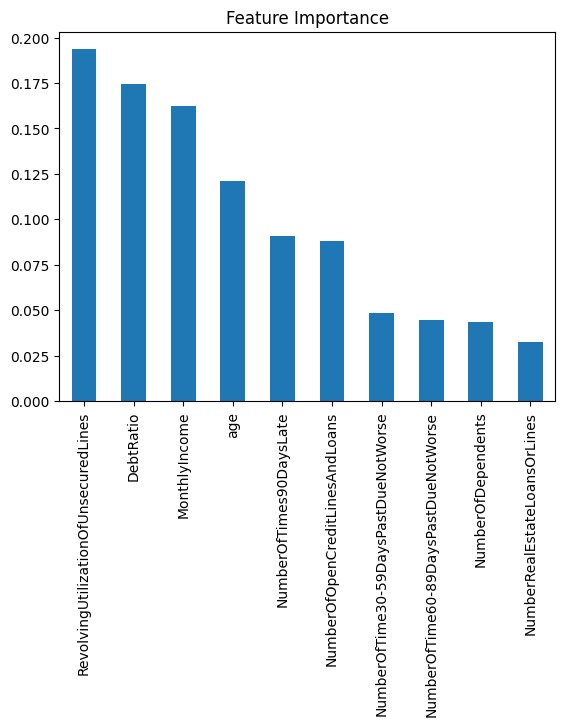

In [51]:
# from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train_imputed, y_train)

importance = pd.Series(
    model.feature_importances_,
    index=X_train_imputed.columns
).sort_values(ascending=False)

importance.head(10).plot(kind='bar')
plt.title("Feature Importance")
plt.show()

In [52]:
importance

RevolvingUtilizationOfUnsecuredLines   0.19
DebtRatio                              0.17
MonthlyIncome                          0.16
age                                    0.12
NumberOfTimes90DaysLate                0.09
NumberOfOpenCreditLinesAndLoans        0.09
NumberOfTime30-59DaysPastDueNotWorse   0.05
NumberOfTime60-89DaysPastDueNotWorse   0.04
NumberOfDependents                     0.04
NumberRealEstateLoansOrLines           0.03
dtype: float64

In [53]:
importance_df = pd.DataFrame({
    'Feature': X_train_imputed.columns,
    'Importance': model.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

importance_df['Percentage (%)'] = importance_df['Importance'] * 100
importance_df['Cumulative (%)'] = importance_df['Percentage (%)'].cumsum()

In [54]:
importance_df

,Feature,Importance,Percentage (%),Cumulative (%)
0,RevolvingUtilizationOfUnsecuredLines,0.19,19.35,19.35
1,DebtRatio,0.17,17.44,36.79
2,MonthlyIncome,0.16,16.25,53.04
3,age,0.12,12.13,65.17
4,NumberOfTimes90DaysLate,0.09,9.08,74.26
5,NumberOfOpenCreditLinesAndLoans,0.09,8.80,83.05
6,NumberOfTime30-59DaysPastDueNotWorse,0.05,4.85,87.90
7,NumberOfTime60-89DaysPastDueNotWorse,0.04,4.48,92.38
8,NumberOfDependents,0.04,4.34,96.72
9,NumberRealEstateLoansOrLines,0.03,3.28,100.00


## Model Training

In [55]:
# Fit model to a Logistic Regression Model

# from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(class_weight='balanced')

lr_model.fit(X_train_imputed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [56]:
# Check the coefficients to check the impact of each feature

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(coef_df)

                                Feature  Coefficient
6               NumberOfTimes90DaysLate         0.63
2  NumberOfTime30-59DaysPastDueNotWorse         0.50
8  NumberOfTime60-89DaysPastDueNotWorse         0.37
7          NumberRealEstateLoansOrLines         0.08
4                         MonthlyIncome         0.05
9                    NumberOfDependents         0.02
5       NumberOfOpenCreditLinesAndLoans         0.00
3                             DebtRatio         0.00
0  RevolvingUtilizationOfUnsecuredLines        -0.01
1                                   age        -0.46


In [57]:
# from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# Get Probabilities
y_probs = lr_model.predict_proba(X_val_imputed)[:, 1]

# Calculate AUC-ROC
auc = roc_auc_score(y_val, y_probs)
print(f"The AUC-ROC Score is: {auc:.4f}")

# View the Confusion Matrix (using 0.5 as the default threshold)
y_pred = lr_model.predict(X_val_imputed)
cm = confusion_matrix(y_val, y_pred)

print(classification_report(y_val, y_pred))

The AUC-ROC Score is: 0.8202
              precision    recall  f1-score   support

           0       0.97      0.88      0.92     27995
           1       0.27      0.63      0.37      2005

    accuracy                           0.86     30000
   macro avg       0.62      0.75      0.65     30000
weighted avg       0.92      0.86      0.88     30000



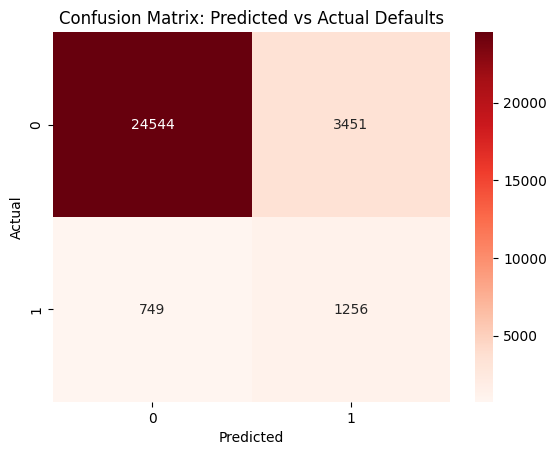

In [58]:
# plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title('Confusion Matrix: Predicted vs Actual Defaults')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

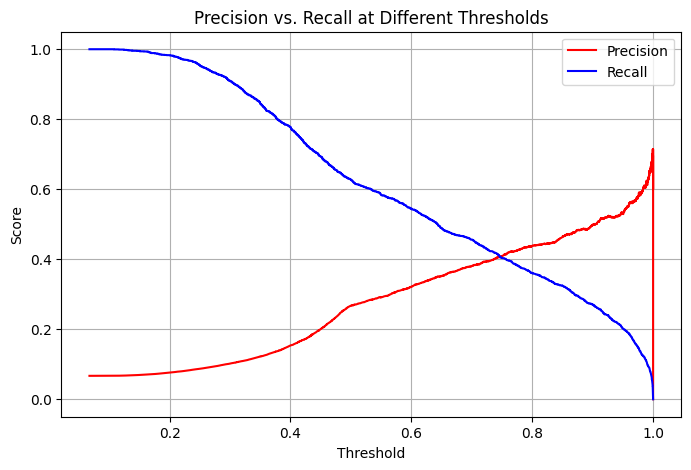

In [59]:
# from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_val, y_probs)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label="Precision", color='red')
plt.plot(thresholds, recall[:-1], label="Recall", color='blue')
plt.title("Precision vs. Recall at Different Thresholds")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

In [60]:
# from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_val, y_probs)
# Find the optimal threshold
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"The mathematically 'optimal' threshold is: {optimal_threshold:.4f}")

The mathematically 'optimal' threshold is: 0.4835


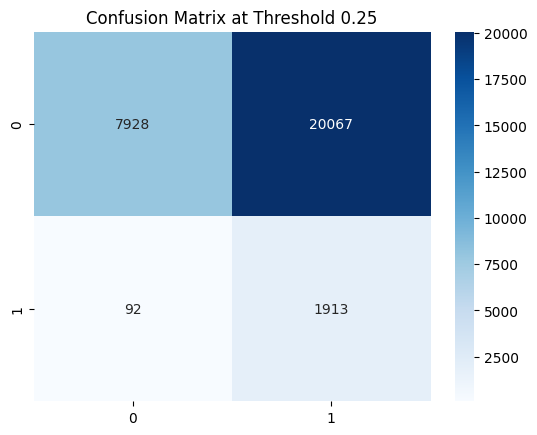

              precision    recall  f1-score   support

           0       0.99      0.28      0.44     27995
           1       0.09      0.95      0.16      2005

    accuracy                           0.33     30000
   macro avg       0.54      0.62      0.30     30000
weighted avg       0.93      0.33      0.42     30000



In [61]:
# Apply the custom threshold
custom_threshold = 0.25 
y_pred_custom = (y_probs >= custom_threshold).astype(int)

# View the new Confusion Matrix
cm_custom = confusion_matrix(y_val, y_pred_custom)
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix at Threshold {custom_threshold}')
plt.show()

print(classification_report(y_val, y_pred_custom))

### Create bins for the feature `RevolvingUtilizationOfUnsecuredLines` as it showed High importance as per RF model but almost negligible for LR model (Refer Feature importance and Model training section below) This behaviour could be due to existance of non-linear data. Binning would help in fixing it.

In [ ]:
def apply_credit_binning(df, features_to_bin):
    """
    Automatically creates bins for specified features and 
    returns a dataframe with dummy variables.
    """
    df_binned = df.copy()
    
    for col in features_to_bin:

        df_binned[f'{col}_bin'] = pd.qcut(df[col], q=5, labels=False, duplicates='drop')    # duplicates='drop' handles cases where many people have 0 utilization
        
        # Convert to dummy variables (One-Hot Encoding)
        dummies = pd.get_dummies(df_binned[f'{col}_bin'], prefix=f'{col}_grp', drop_first=True)
        df_binned = pd.concat([df_binned, dummies], axis=1)
        
        # Drop the original and the intermediate bin column
        df_binned.drop([col, f'{col}_bin'], axis=1, inplace=True)
        
    return df_binned

top_features = ['RevolvingUtilizationOfUnsecuredLines']

df_train_binned = apply_credit_binning(df_train, top_features)
df_train_binned

,SeriousDlqin2yrs,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,RevolvingUtilizationOfUnsecuredLines_grp_1,RevolvingUtilizationOfUnsecuredLines_grp_2,RevolvingUtilizationOfUnsecuredLines_grp_3,RevolvingUtilizationOfUnsecuredLines_grp_4
0,1,45,2.00,0.80,9120.00,13,0.00,6,0.00,2.00,False,False,False,True
1,0,40,0.00,0.12,2600.00,4,0.00,0,0.00,1.00,False,False,False,True
2,0,38,1.00,0.09,3042.00,2,1.00,0,0.00,0.00,False,False,True,False
3,0,30,0.00,0.04,3300.00,5,0.00,0,0.00,0.00,False,True,False,False
4,0,49,1.00,0.02,63588.00,7,0.00,1,0.00,0.00,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,0,74,0.00,0.23,2100.00,4,0.00,1,0.00,0.00,True,False,False,False
149996,0,44,0.00,0.72,5584.00,4,0.00,1,0.00,2.00,False,False,True,False
149997,0,58,0.00,3870.00,NaN,18,0.00,1,0.00,0.00,False,True,False,False
149998,0,30,0.00,0.00,5716.00,4,0.00,0,0.00,0.00,False,False,False,False
